# Benchmarking OncoTox with the real **DrEval** (`drevalpy` 1.5.1)

Runs our data and our model through the **actual published benchmarking framework**, not a
re-implementation:

> Bernett, Iversen, Picciani, **Wilhelm**, Baum, List —
> *Critical evaluation of drug response prediction models with DrEval*, **Nat. Commun. (2026)**
> · package: <https://github.com/daisybio/drevalpy> · `pip install drevalpy` (v1.5.1 used here)

**Their headline:** *"deep learning models barely outperform a naive model that predicts only the mean
drug and cell line effects"* — about half of published models fail to beat their
`NaiveMeanEffectsPredictor`. Our own finding that **ridge on 150 cell-line means ties the PCA MLP**
(notebook `ablations_and_rescue`) is the same result, independently reproduced. This notebook checks our model against
**their** baselines, **their** splits and **their** metrics.

### What is imported from `drevalpy` (nothing re-implemented)

| Their component | What we use it for |
|---|---|
| `DrugResponseDataset` | our (cell line × drug) AUC responses in their format |
| `.split_dataset(mode="LCO")` | **their** leave-cell-line-out CV splits (the personalized-medicine setting) |
| `NaivePredictor`, `NaiveDrugMeanPredictor`, `NaiveCellLineMeanPredictor`, **`NaiveMeanEffectsPredictor`** | their baselines — the bar half the field fails to clear |
| `SingleDrugRandomForest`, `SingleDrugElasticNet` | their per-drug reference models, fed **our** scGPT / PCA embeddings as the cell-line view |
| `evaluate()` | their metric implementations (Pearson / Spearman / R²) |
| their normalization recipe | subtract `NaiveMeanEffects` predictions from **y_true *and* y_pred**, then re-evaluate |

**Our model (`OncoMLP`) is trained on their splits**: single cells of the *train* lines, predictions on
the cells of the held-out lines, averaged back to one value per cell line — so it is scored on exactly
the same pairs as their models.

### One thing worth knowing before reading the numbers

In **LCO**, a held-out cell line was never seen, so `NaiveMeanEffectsPredictor` sets its cell-line effect
to **0** — the baseline reduces to *global mean + drug effect*. That has two consequences:

1. `NaiveMeanEffects` ≡ `NaiveDrugMean` in this setting (we verify it below).
2. Their **normalized** metric therefore removes the **drug** mean — which is exactly the fix for the
   Simpson's-paradox artifact they describe (pooled ρ looks great merely because drugs differ in
   potency). It does **not** remove the cell-line effect, because in LCO no honest predictor can know it.

**Target:** `--score auc` (native, un-z-scored AUC units), because DrEval works per (cell line × drug)
pair and their naive predictors estimate the drug means themselves.

> ⚠️ **The stored outputs below predate the score fix (12.08.2026), and this notebook cannot be re-run yet.** Every number in it was computed on the retired **`auc`** target and the void 8-drug panel. The code now reads `DEFAULT_CTRP_SCORE` (`auc_cc`), but the cell that imports `dreval_normalize` still raises: three of the functions it wants were deleted on 12.08.2026 with the cell-line-effect diagnostic, and rewiring it is **review item 11**, not a substitution. Outputs are kept rather than cleared so the old measurements stay legible. **R5 re-runs this notebook**, after item 11.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'    # outputs always live in notebooks/outputs
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader

import drevalpy
from drevalpy.datasets.dataset import DrugResponseDataset, FeatureDataset
from drevalpy.evaluation import evaluate
from drevalpy.models import MODEL_FACTORY

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'
print('drevalpy', drevalpy.__version__)
print('available models:', sorted(MODEL_FACTORY.keys())[:8], '...')

drevalpy 1.5.1
available models: ['AdaBoostDecisionTree', 'DIPK', 'DrugGNN', 'ElasticNet', 'GradientBoosting', 'KNNRegressor', 'Lasso', 'MOLIR'] ...


## 1. Our data → their `DrugResponseDataset`

DrEval operates at **(cell line × drug)** resolution — which is the honest resolution of our label
anyway (it is a bulk measurement broadcast to cells). Cell-line features = the **mean embedding** of that
line's cells, for both representations.

In [2]:
lrn = pd.read_csv(OUT / 'legacy' / 'learnability' / 'ctrp_drug_learnability_auc.csv')
# learnability = min(#killed, #spared), gate: coverage >= 90%  -> top 10  (see 08_learnability_filter)
FIVE = lrn[lrn['selected']].sort_values('learnability', ascending=False)['drug'].tolist()

# DEFAULT_CTRP_SCORE, not a literal: 'auc' was removed from CTRP_SCORES on 11.08.2026, so
# this raised ValueError on construction. auc_cc is also in native viability units, which is
# what DrEval needs -- it works per (cell line x drug), so a per-drug standardised target
# would make its pooled metrics meaningless (12.08.2026).
paths = PipelinePaths.build(None, 'hvg5000', DEFAULT_CTRP_SCORE)
ad = sc.read_h5ad(paths.targets_h5ad)
Y = np.asarray(ad.obsm['Y_ctrp'], float)
M = np.asarray(ad.obsm['M_ctrp'], bool)
ALL = list(ad.uns['ctrp_drugs'])
lines = ad.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)
E = {'scgpt': np.asarray(ad.obsm['X_scGPT'], float), 'pca': np.asarray(ad.obsm['X_pca'], float)}

pairs, cell_feats_d = [], {}
for l in uniq:
    ci = np.flatnonzero(lines == l)
    cell_feats_d[l] = {'cell_line_name': np.array([l]),
                       'scgpt': E['scgpt'][ci].mean(0),      # line = mean of its cells
                       'pca': E['pca'][ci].mean(0)}
    for d in FIVE:
        k = ALL.index(d)
        obs = ci[M[ci, k]]
        if obs.size:
            pairs.append((l, d, Y[obs, k].mean()))

response = DrugResponseDataset(
    response=np.array([p[2] for p in pairs], dtype=float),
    cell_line_ids=np.array([p[0] for p in pairs]),
    drug_ids=np.array([p[1] for p in pairs]),
    dataset_name='OncoTox_SCP542_CTRPv2',
)
cell_feats = FeatureDataset(features=cell_feats_d)
drug_feats = FeatureDataset(features={d: {'pubchem_id': np.array([d])} for d in FIVE})

print(f'{len(pairs)} (cell line x drug) pairs | {len({p[0] for p in pairs})} cell lines | {len(FIVE)} drugs')
print('drugs:', FIVE)

1712 (cell line x drug) pairs | 180 cell lines | 10 drugs
drugs: ['daporinad', 'ml210', 'gsk461364', 'oligomycin a', 'kx2-391', 'methotrexate', 'rigosertib', 'snx-2112', 'dasatinib', 'ml162']


## 2. Their LCO splits (leave-cell-line-out)

DrEval's four settings: **LPO** (imputation), **LCO** (*personalized medicine — a new patient*), **LTO**
(drug repurposing across tissues), **LDO** (novel drug discovery). Ours is **LCO** — the same leakage
control we already used (no cell line in both train and test), now produced by *their* code.

In [3]:
response.split_dataset(n_cv_splits=5, mode='LCO', split_validation=True,
                       validation_ratio=0.1, random_state=42)
folds = response.cv_splits
tr0, te0 = folds[0]['train'], folds[0]['test']
print(f'{len(folds)} LCO folds')
print(f'fold 1: train {len(tr0.response)} pairs / {len(set(tr0.cell_line_ids))} lines | '
      f'test {len(te0.response)} pairs / {len(set(te0.cell_line_ids))} lines')
print('line overlap train/test:', set(tr0.cell_line_ids) & set(te0.cell_line_ids), '(empty = leakage-free)')

5 LCO folds
fold 1: train 1226 pairs / 129 lines | test 339 pairs / 36 lines
line overlap train/test: set() (empty = leakage-free)


## 3. Models

- **Their baselines** — incl. `NaiveMeanEffectsPredictor`, the bar half the published field fails.
- **Their `SingleDrugRandomForest` / `SingleDrugElasticNet`**, fed **our** embeddings as the cell-line
  view — i.e. their reference models on our features.
- **Our `OncoMLP`** — trained on the *single cells* of the train lines (the actual OncoTox pipeline),
  predictions averaged back to one value per held-out cell line.

In [4]:
def run_naive(name, tr, te):
    m = MODEL_FACTORY[name]()
    m.build_model({})
    m.train(output=tr, cell_line_input=cell_feats, drug_input=drug_feats)
    return m.predict(cell_line_ids=te.cell_line_ids, drug_ids=te.drug_ids,
                     cell_line_input=cell_feats, drug_input=drug_feats)


def run_their_model(name, view, tr, te):
    """Their SingleDrug* model, using OUR embedding as the cell-line view."""
    m = MODEL_FACTORY[name]()
    hp = MODEL_FACTORY[name].get_hyperparameter_set()[0].copy()
    hp['cell_line_views'] = view
    m.build_model(hp)
    preds = np.full(len(te.response), np.nan)
    for d in np.unique(te.drug_ids):                 # SingleDrug models are fit per drug
        tr_d = DrugResponseDataset(
            response=tr.response[tr.drug_ids == d], cell_line_ids=tr.cell_line_ids[tr.drug_ids == d],
            drug_ids=tr.drug_ids[tr.drug_ids == d])
        mm = MODEL_FACTORY[name]()
        mm.build_model(hp)
        mm.train(output=tr_d, cell_line_input=cell_feats, drug_input=drug_feats)
        sel = te.drug_ids == d
        preds[sel] = mm.predict(cell_line_ids=te.cell_line_ids[sel], drug_ids=te.drug_ids[sel],
                                cell_line_input=cell_feats, drug_input=drug_feats)
    return preds


def run_oncomlp(rep, tr, va, te):
    """OUR model: train on the single cells of the train lines, predict the held-out lines' cells.

    Early stopping / best-epoch selection runs on DrEval's own VALIDATION split (`sp['validation']`).
    Using the test fold here would select the model on the data it is scored on.
    """
    tr_lines, va_lines, te_lines = set(tr.cell_line_ids), set(va.cell_line_ids), set(te.cell_line_ids)
    assert not (tr_lines | va_lines) & te_lines, 'test lines leaked into train/val'
    trc = np.isin(lines, list(tr_lines))
    vac = np.isin(lines, list(va_lines))
    tec = np.isin(lines, list(te_lines))
    tr_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=trc, drugs=FIVE)
    va_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=vac, drugs=FIVE)
    model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                    dropout_rate=0.5, input_dropout=0.1, norm='layer',
                    output_dim=len(tr_ds.drug_names))
    best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True),
                          DataLoader(va_ds, batch_size=256, shuffle=False),
                          # epochs=50 explicitly (Selin, 12.08.2026, review item 10). This cell was the only
        # caller in the project that passed no `epochs` at all, so it fell through to
        # TrainConfig's default of 25 while 4a_percell_training and verify_variants both
        # pass 50. That is not a benchmark setting anyone chose: it meant the notebook
        # answering "how strong is this by the field's standard" trained our model for
        # half as long as the pipeline it represents, biasing the comparison against us.
        # Setting it restores the pipeline's configuration rather than changing the
        # benchmark.
        config=TrainConfig(epochs=50, seed=42, log_every=1000),
                          tag=f'dreval_{rep}', drug_names=tr_ds.drug_names)
    best = best.to('cpu').eval()
    with torch.no_grad():
        X = torch.tensor(np.asarray(ad.obsm[rep], dtype=np.float32)[tec])
        P = best(X).numpy()                          # (cells of held-out lines, 5)
    cell_lines_te = lines[tec]
    per_line = {(l, d): P[cell_lines_te == l, j].mean()
                for l in te_lines for j, d in enumerate(FIVE)}
    return np.array([per_line[(l, d)] for l, d in zip(te.cell_line_ids, te.drug_ids)])

In [5]:
BASELINES = ['NaivePredictor', 'NaiveDrugMeanPredictor', 'NaiveCellLineMeanPredictor',
             'NaiveMeanEffectsPredictor']
records = []
for fold, sp in enumerate(folds, 1):
    tr, va, te = sp['train'], sp['validation'], sp['test']
    preds = {b: run_naive(b, tr, te) for b in BASELINES}
    for view in ['pca', 'scgpt']:
        preds[f'SingleDrugRF ({view})'] = run_their_model('SingleDrugRandomForest', view, tr, te)
        preds[f'SingleDrugEN ({view})'] = run_their_model('SingleDrugElasticNet', view, tr, te)
    preds['OncoMLP (X_pca)'] = run_oncomlp('X_pca', tr, va, te)
    preds['OncoMLP (X_scGPT)'] = run_oncomlp('X_scGPT', tr, va, te)

    naive = preds['NaiveMeanEffectsPredictor']       # <- their normalization reference
    for algo, p in preds.items():
        raw = evaluate(DrugResponseDataset(response=te.response, cell_line_ids=te.cell_line_ids,
                                           drug_ids=te.drug_ids, predictions=p),
                       ['Pearson', 'Spearman', 'R^2'])
        # DrEval normalization: subtract the NaiveMeanEffects prediction from y_true AND y_pred
        norm = evaluate(DrugResponseDataset(response=te.response - naive, cell_line_ids=te.cell_line_ids,
                                            drug_ids=te.drug_ids, predictions=p - naive),
                        ['Pearson', 'Spearman', 'R^2'])
        records.append({'fold': fold, 'algorithm': algo,
                        **{f'{k}': v for k, v in raw.items()},
                        **{f'{k}: normalized': v for k, v in norm.items()}})
    print(f'fold {fold} done', flush=True)

res = pd.DataFrame(records)
res.to_csv(OUT / 'dreval' / 'dreval_lco_results.csv', index=False)

summary = res.groupby('algorithm')[['Pearson', 'Spearman', 'R^2',
                                    'Pearson: normalized', 'Spearman: normalized', 'R^2: normalized']].mean()
order = BASELINES + [c for c in summary.index if c not in BASELINES]
summary = summary.loc[order]
print('\n=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===')
print(summary.round(3).to_string())

Loaded 33321 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.5 | min drug coverage=29891 cells | max drug coverage=33321 cells.
Loaded 3757 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.8 | min drug coverage=3390 cells | max drug coverage=3757 cells.
[dreval_X_pca] Training on device: mps
[dreval_X_pca] Multi-task mode detected (masked MSE).


[dreval_X_pca] Epoch [01/25] | Train MSE: 0.0912 | Val MSE: 0.0268 | LR: 1.0e-03  <- best
  best : snx-2112:0.008(n=3757), dasatinib:0.009(n=3757), ml162:0.012(n=3757), ml210:0.012(n=3757), rigosertib:0.023(n=3555)
  worst: methotrexate:0.062(n=3551), gsk461364:0.055(n=3757), daporinad:0.038(n=3390), oligomycin a:0.027(n=3757), kx2-391:0.024(n=3757)


[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0268 at epoch 1.
Loaded 33321 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.5 | min drug coverage=29891 cells | max drug coverage=33321 cells.
Loaded 3757 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.8 | min drug coverage=3390 cells | max drug coverage=3757 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).


[dreval_X_scGPT] Epoch [01/25] | Train MSE: 0.0815 | Val MSE: 0.0286 | LR: 1.0e-03  <- best
  best : dasatinib:0.009(n=3757), snx-2112:0.011(n=3757), ml162:0.014(n=3757), ml210:0.016(n=3757), rigosertib:0.023(n=3555)
  worst: methotrexate:0.063(n=3551), gsk461364:0.050(n=3757), daporinad:0.046(n=3390), kx2-391:0.029(n=3757), oligomycin a:0.027(n=3757)


[dreval_X_scGPT] Epoch [02/25] | Train MSE: 0.0397 | Val MSE: 0.0285 | LR: 1.0e-03  <- best
  best : dasatinib:0.008(n=3757), snx-2112:0.011(n=3757), ml162:0.014(n=3757), ml210:0.017(n=3757), rigosertib:0.024(n=3555)
  worst: methotrexate:0.062(n=3551), gsk461364:0.049(n=3757), daporinad:0.045(n=3390), oligomycin a:0.032(n=3757), kx2-391:0.026(n=3757)


...

[dreval_X_scGPT] Epoch [04/25] | Train MSE: 0.0325 | Val MSE: 0.0369 | LR: 1.0e-03  <- best
  best : snx-2112:0.012(n=3260), rigosertib:0.017(n=3260), ml210:0.019(n=3086), ml162:0.019(n=3260), dasatinib:0.020(n=3260)
  worst: oligomycin a:0.092(n=3142), gsk461364:0.067(n=3144), methotrexate:0.056(n=3086), kx2-391:0.047(n=3260), daporinad:0.023(n=3133)


[dreval_X_scGPT] Epoch [05/25] | Train MSE: 0.0311 | Val MSE: 0.0369 | LR: 1.0e-03  <- best
  best : snx-2112:0.013(n=3260), rigosertib:0.018(n=3260), dasatinib:0.019(n=3260), ml162:0.020(n=3260), ml210:0.020(n=3086)
  worst: oligomycin a:0.083(n=3142), gsk461364:0.070(n=3144), methotrexate:0.056(n=3086), kx2-391:0.050(n=3260), daporinad:0.024(n=3133)


[dreval_X_scGPT] Epoch [10/25] | Train MSE: 0.0278 | Val MSE: 0.0368 | LR: 5.0e-04  <- best
  best : snx-2112:0.011(n=3260), ml162:0.016(n=3260), ml210:0.016(n=3086), rigosertib:0.018(n=3260), dasatinib:0.019(n=3260)
  worst: oligomycin a:0.089(n=3142), gsk461364:0.067(n=3144), methotrexate:0.058(n=3086), kx2-391:0.052(n=3260), daporinad:0.026(n=3133)


[dreval_X_scGPT] Early stopping at epoch 20 (no val improvement for 10 epochs).
[dreval_X_scGPT] Training complete. Best Val MSE: 0.0368 at epoch 10.
fold 5 done



=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===
                            Pearson  Spearman    R^2  Pearson: normalized  Spearman: normalized  R^2: normalized
algorithm                                                                                                       
NaivePredictor                0.000     0.000 -0.004                0.019                 0.028           -0.016
NaiveDrugMeanPredictor        0.117     0.102  0.007                0.000                 0.000           -0.004
NaiveCellLineMeanPredictor    0.000     0.000 -0.004                0.019                 0.028           -0.016
NaiveMeanEffectsPredictor     0.117     0.102  0.007                0.000                 0.000           -0.004
OncoMLP (X_pca)               0.335     0.341  0.096                0.318                 0.340            0.086
OncoMLP (X_scGPT)             0.362     0.352  0.124                0.350                 0.357            0.114
SingleDrugEN (pca)  

## 4. Read-out

**Raw** metrics are pooled over all (cell line × drug) pairs and are inflated by drug potency
(Simpson's paradox — DrEval's central complaint). **Normalized** metrics are the honest ones: they
subtract the `NaiveMeanEffects` prediction from truth *and* prediction, leaving only the part a model
adds **beyond knowing the average drug and cell-line effect**.

The question DrEval poses to every model, and now to ours:

> **Does it beat `NaiveMeanEffectsPredictor`?** (Half of the published field does not.)

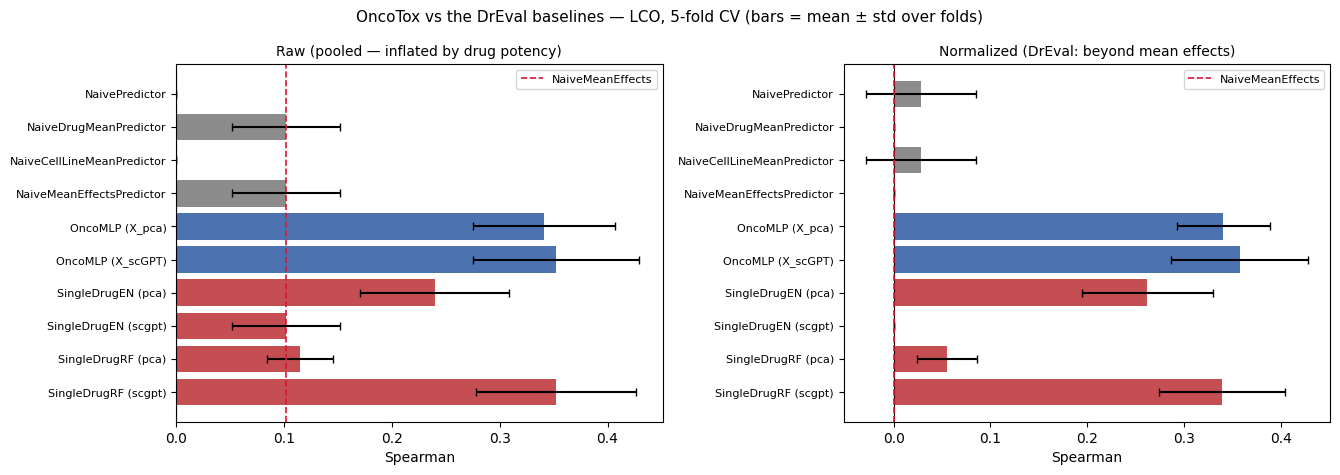

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=False)
piv = res.groupby('algorithm')[['Spearman', 'Spearman: normalized']].agg(['mean', 'std']).loc[order]
x = np.arange(len(order))
# colour by MODEL FAMILY, not by position: grey = DrEval baselines,
# red = their reference models on our features, blue = ours.
cols = ['#4C72B0' if a.startswith('OncoMLP')
        else '#C44E52' if a.startswith('SingleDrug')
        else '#8C8C8C' for a in order]

for a, col, title in [(ax[0], 'Spearman', 'Raw (pooled — inflated by drug potency)'),
                      (ax[1], 'Spearman: normalized', 'Normalized (DrEval: beyond mean effects)')]:
    m = piv[(col, 'mean')].to_numpy(); s = piv[(col, 'std')].to_numpy()
    a.barh(x, m, xerr=s, color=cols, capsize=3)
    a.axvline(0, color='k', lw=0.8)
    nme = piv.loc['NaiveMeanEffectsPredictor', (col, 'mean')]
    a.axvline(nme, color='crimson', ls='--', lw=1.2, label='NaiveMeanEffects')
    a.set_yticks(x); a.set_yticklabels(order, fontsize=8)
    a.invert_yaxis(); a.set_xlabel('Spearman'); a.set_title(title, fontsize=10); a.legend(fontsize=8)

fig.suptitle('OncoTox vs the DrEval baselines — LCO, 5-fold CV (bars = mean ± std over folds)', fontsize=11)
fig.tight_layout()
fig.savefig(OUT / 'dreval' / 'dreval_lco.png', dpi=200)
plt.show()

## Conclusion

*(Filled in from the executed cells — see `outputs/dreval/dreval_lco_results.csv`.)*

Three things this notebook establishes, using the field's own benchmark rather than our metrics:

1. **Whether OncoTox clears `NaiveMeanEffectsPredictor`** — the bar that half of the published models in
   the DrEval paper fail. Our own `ablations_and_rescue` ablation (ridge on line-means ties the PCA MLP) predicts this is
   *tight*, and the normalized column is where it is decided.
2. **PCA vs scGPT under their protocol**, on their splits, with their metrics — an external check on the
   +0.075 gap we measured ourselves.
3. **Our model vs their reference models** (`SingleDrugRandomForest` / `SingleDrugElasticNet`) fed the
   *same* embeddings — i.e. does the single-cell MLP add anything over a standard per-drug regressor on
   the line-mean embedding?

⚠️ **Caveat that still applies:** the 5 drugs were selected with a filter that saw all 180 cell lines
(notebook `learnability_filter`), so this is a **best-case subset**, not a random one. DrEval's protocol fixes the
*evaluation*; it does not fix our *selection*. Train-only selection remains the blocking next step.

## 5. Does the signal survive removing the **cell-line** effect? (our extension)

Section 4 used DrEval's normalization, which in LCO removes the **drug** mean only -- a held-out line
was never seen, so no honest predictor can know its cell-line effect (see the note in section 3). That
leaves the other half of the question open:

> Is our per-drug correlation genuine drug-specific biology, or just *"this cell line is fragile"*?

The cell-line effect is large -- sigma ~ 0.40 on the raw AUC scale -- so a model can score a good
per-drug Spearman by learning general fragility alone. This section removes it as well. It is
deliberately **not** a legitimate predictor (it reads held-out labels); it is a diagnostic.

**Producer:** `scripts/evaluation/dreval_normalize.py` -- importable functions plus a CLI, so this
section and the command line cannot drift. Two design points documented in that module and worth
repeating here:

- The fragility index `c` is estimated over **all 545 drugs**, leaving out the drug being scored.
  Estimating it from the small panel injects the estimate's own noise into *both* residuals and
  manufactures correlation: on a synthetic control where the model has learned *nothing but*
  fragility, a 3-drug estimate scores `rho_normalized` = 0.94 instead of 0.
- The correction is a **partial** Spearman (regress `c` out of both rank vectors), not DrEval's unit
  subtraction. Unit subtraction is valid in DrEval because its naive predictor is fitted in the
  response's own units; `c` is in per-drug z units, and subtracting it with coefficient 1 leaves a
  residual proportional to fragility in both series (0.62 instead of 0 on the same control).

Reading the output: a drug with a **high** `rho_naive_baseline` and a `rho_normalized` near **0** had
no drug-specific signal -- its apparent performance *was* the cell-line effect. That is the artifact
class DrEval describes, found in our own results.


In [ ]:
# Rewired to DrEval's own recipe (Selin, 12.08.2026, review item 11). This cell used to call
# line_by_drug_truth / normalized_correlations / oof_line_predictions, deleted with the
# cell-line-effect diagnostic -- a locally invented metric with no counterpart in DrEval's paper.
# That diagnostic is NOT restored; it stays retired, recoverable at
#   git show bf93084:scripts/evaluation/dreval_normalize.py
#
# The substantive change is that this no longer TRAINS. It used to refit 20 models of its own
# (K=panel and K=545, x 2 reps) purely to produce predictions to normalize. Those were a second,
# separate training path whose configuration could drift from the pipeline's -- and did: see the
# epoch fix in cell 8, where this notebook was training for 25 epochs while everything else ran 50.
# Now it reads the out-of-fold predictions 4a_percell_training already wrote, so the benchmark
# scores the models the pipeline actually produced rather than lookalikes of them.
from scripts.evaluation.dreval_normalize import load_oof, normalized_evaluation

OOF_CSV = OUT / 'panel' / 'panel_oof_predictions.csv'
NORM_CSV = OUT / 'dreval' / 'dreval_normalized.csv'

# load_oof refuses a frame without a `fold` column, because DrEval's naive baseline has to be fitted
# on the training folds -- fitting it on the same out-of-fold rows it is then subtracted from would
# let held-out labels define the baseline they are scored against.
if OOF_CSV.exists():
    frames = []
    for rep in ['X_pca', 'X_scGPT']:
        for weighted in [False, True]:
            oof = load_oof(OOF_CSV, rep=rep, weighted=weighted)
            if oof.empty:
                continue
            block = normalized_evaluation(oof)
            block.insert(0, 'weighted', weighted)
            block.insert(0, 'rep', rep)
            frames.append(block)
    norm = pd.concat(frames, ignore_index=True)
    norm.to_csv(NORM_CSV, index=False)
    print(f'{len(norm)} rows from {OOF_CSV.name} -> {NORM_CSV.name}')
else:
    raise FileNotFoundError(
        f'{OOF_CSV} does not exist yet. It is written by 4a_percell_training at R4 of the sweep. '
        f'The previously cached {NORM_CSV.name} is NOT read as a fallback: it predates the '
        f'val-split fix (ee07b00), was computed on the void 8-drug panel, and its rho_normalized '
        f'came from code that no longer exists. Falling back to it would print stale numbers that '
        f'look current.'
    )

print(norm.round(3).to_string(index=False))
